<a href="https://colab.research.google.com/github/MiguelAtencio/deep-learning-copilot/blob/main/ML4BI_E5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for BI 2

## Deep Learning exercises for week 5

The goal of this exercise is for students to gain hands-on experience in applying Convolutional Neural Networks (CNNs) to a novel dataset, understand the process of data preparation, model building, training, and evaluation. This will involve experimenting with different model architectures, hyperparameters, and techniques to improve model performance.

**About the CIFAR-10 dataset**

The CIFAR-10 dataset is a widely-used dataset for benchmarking machine learning algorithms, especially in the field of image recognition. It consists of 60,000 32x32 color images in 10 different classes, with 6,000 images per class. The dataset is divided into 50,000 training images and 10,000 test images. The classes represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. Each image is labeled with one of these 10 classes, making it a standard dataset for evaluating algorithms for image classification tasks.

The CIFAR-10 dataset was created by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton and is a subset of the 80 million tiny images dataset. Due to its moderate size and complexity, CIFAR-10 serves as an excellent benchmark for algorithms and techniques in computer vision, particularly for methodologies that are aimed at performing well on small to medium-sized datasets in image recognition tasks.

**Load and prepare the data**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Class names in the CIFAR-10 dataset
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


**Plot images**

Plot some images from the dataset.

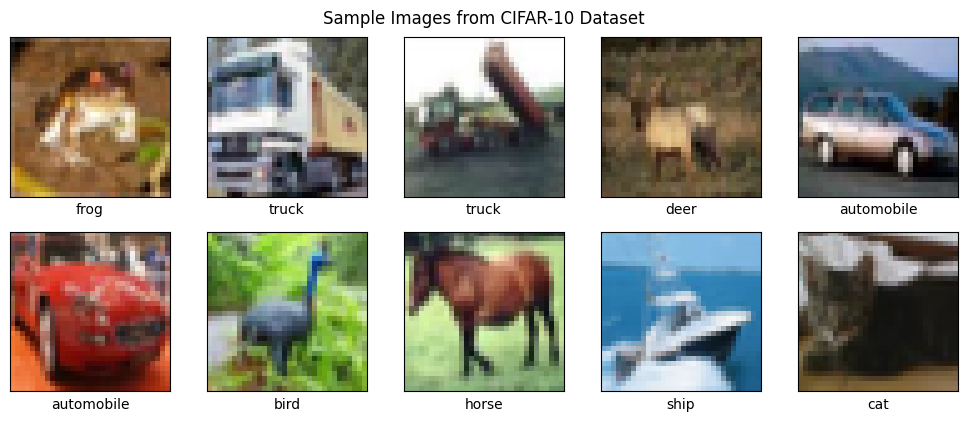

In [3]:
plt.figure(figsize=(10, 10))

for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR-10 labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])

plt.suptitle('Sample Images from CIFAR-10 Dataset')
plt.tight_layout()
plt.show()

**Model building**

Build a convnet without adding data augmentation.

In [25]:
input = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(input)
x = layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)  # 30
x = layers.MaxPooling2D(pool_size=2)(x)                             # 15
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)  # 13
x = layers.MaxPooling2D(pool_size=2)(x)                             # 6
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x) # 4
x = layers.MaxPooling2D(pool_size=2)(x)                             # 2
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(10, activation='softmax')(x)

**Compile and train the model**

In [26]:
model = keras.Model(inputs=input, outputs=output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=50, batch_size=128, validation_split=0.2)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 97ms/step - accuracy: 0.3286 - loss: 1.8071 - val_accuracy: 0.4117 - val_loss: 1.5909
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.4542 - loss: 1.5121 - val_accuracy: 0.4724 - val_loss: 1.4614
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5077 - loss: 1.3939 - val_accuracy: 0.5203 - val_loss: 1.3506
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5415 - loss: 1.2977 - val_accuracy: 0.5543 - val_loss: 1.2715
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5724 - loss: 1.2282 - val_accuracy: 0.5778 - val_loss: 1.2163
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.5942 - loss: 1.1636 - val_accuracy: 0.6046 - val_loss: 1.1516
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.6114 - loss: 1.1189 - val_accuracy: 0.6052 - val_loss: 1.1392
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.6293 - loss: 1.0718 - 

**Plotting Training and Validation Loss and Accuracy**

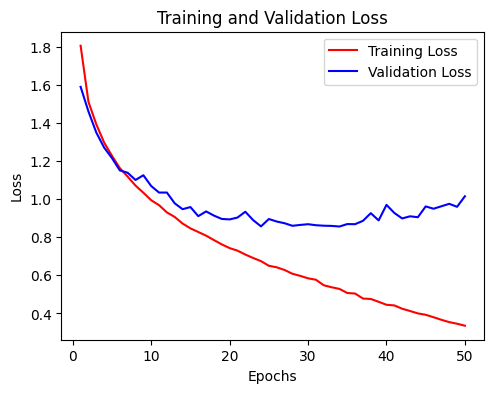

In [28]:
plt.figure(figsize=(12, 4))

epochs = range(1, len(history.history['loss']) + 1)
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'r-', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'b-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

**Test data evaluation**

In [ ]:
best_epoch = history.history["val_loss"].index(min(history.history["val_loss"])) + 1
best_epoch

34

The best model here is not chosen. Here the overfitted model is chosen.
To choose the correct model, I would have to find the best epoch against the validation loss or accuracy, and then also multiply the epochs by a factor equivalent to the validation split

In [36]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

313/313 - 2s - 8ms/step - accuracy: 0.7042 - loss: 1.0520


## Data augmentation addition

Now, add a data augmentation step and compare model performance.

**Model building**

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2)
]

def augment_data(image, label):
    for layer in data_augmentation_layers:
        image = layer(image, training=True)
    return image, label

val_split = 0.2
split_idx = int(len(train_images) * (1 - val_split))

train_ds = tf.data.Dataset.from_tensor_slices((train_images[:split_idx], train_labels[:split_idx]))
val_ds   = tf.data.Dataset.from_tensor_slices((train_images[split_idx:], train_labels[split_idx:]))

train_ds = train_ds.batch(128).map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.batch(128) 


**Compile and train the model**

In [52]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="conv_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

input = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1./255)(input)
x = layers.Conv2D(filters=32, kernel_size=3, activation='relu')(x)  # 30
x = layers.MaxPooling2D(pool_size=2)(x)                             # 15
x = layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)  # 13
x = layers.MaxPooling2D(pool_size=2)(x)                             # 6
x = layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x) # 4
x = layers.MaxPooling2D(pool_size=2)(x)                             # 2
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs=input, outputs=output)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=10, batch_size=128, callbacks=callbacks, validation_data=val_ds)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.2897 - loss: 1.9214 - val_accuracy: 0.3606 - val_loss: 1.7175
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.3951 - loss: 1.6611 - val_accuracy: 0.4301 - val_loss: 1.5599
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.4392 - loss: 1.5582 - val_accuracy: 0.4625 - val_loss: 1.4954
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.4660 - loss: 1.4929 - val_accuracy: 0.4876 - val_loss: 1.4263
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.4880 - loss: 1.4394 - val_accuracy: 0.5022 - val_loss: 1.4051
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.5044 - loss: 1.3913 - val_accuracy: 0.5195 - val_loss: 1.3508
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.5184 - loss: 1.3594 - val_accuracy: 0.5491 - val_loss: 1.2849
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.5300 - loss: 1

**Plotting Training and Validation Loss and Accuracy**

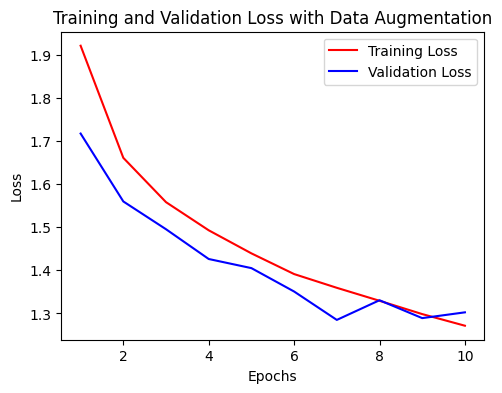

In [53]:
plt.figure(figsize=(12, 4))
epochs = range(1, len(history.history['loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'r-', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'b-', label='Validation Loss')
plt.title('Training and Validation Loss with Data Augmentation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

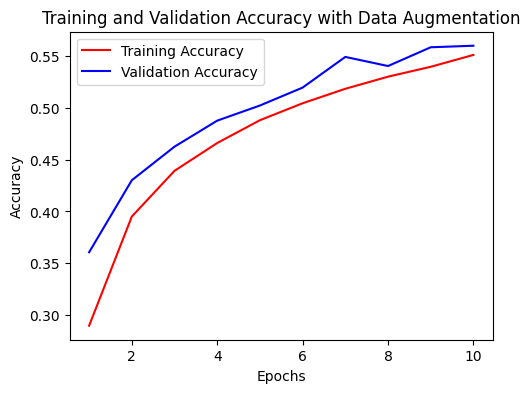

In [54]:
plt.figure(figsize=(12, 4))
epochs = range(1, len(history.history['accuracy']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], 'r-', label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'b-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Data Augmentation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Experiment with more data augmentation
Try experimenting with adding more data augmentation techniques

In [55]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),           # Randomly mirrors the image left-to-right
    layers.RandomRotation(0.1),               # Randomly rotates up to 10% of a full turn (36°)
    layers.RandomZoom(0.2),                   # Randomly zooms in or out by up to 20%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Randomly shifts the image up/down and left/right by up to 10%
    layers.RandomBrightness(factor=0.2),      # Randomly increases or decreases brightness by up to 20%
    layers.RandomContrast(factor=0.2),        # Randomly adjusts the difference between light and dark areas by up to 20%
]